In [7]:
from astropy.cosmology import Planck18
from zdm.zdm import cosmology as cos
from zdm.zdm import misc_functions
from zdm.zdm import parameters
from zdm.zdm import figures
#from zdm import survey
from zdm.zdm import pcosmic
#from zdm import iteration as it
from zdm.zdm import loading
#from zdm import io
import matplotlib.pyplot as plt

import numpy as np
#from matplotlib import pyplot as plt
from pkg_resources import resource_filename
#import time

In [13]:




def set_state(nz):
    """
    Initializes the state with the given power-law index for redshift evolution of host DM contribution (n_z).
    """
    param_dict={'sfr_n': 0.21, 'alpha': 0.92, 'lmean': 2.02, 'lsigma': 0.46, 'lEmax': 41.42, 
                'lEmin': 39.49, 'gamma': -1.16, 'H0': 73, 'halo_method': 0, 'sigmaDMG': 0.0, 'sigmaHalo': 0.0,
                'lC': -7.61, 'min_lat': 0.0, 'n_z': nz}
    state = parameters.State()
    state.set_astropy_cosmo(Planck18)
    state.update_params(param_dict)

    # Initialize with state parameters
    #cos.set_cosmology(state.params)
    #cos.init_dist_measures()
    return state



def creategrid(state):
    # creates a grid object with the given state parameters
    surveys, grids = loading.surveys_and_grids(init_state=state, survey_names = names,   
        repeaters=False, sdir=sdir)
    
    return surveys,grids
    



def mask_plot( dmvals, zvals, state):
    """
    Plots the DM mask as a function of DM and redshift for a given state.
    """
    mask = pcosmic.get_dm_mask(dmvals, (state.host.lmean, state.host.lsigma, state.host.n_z), zvals)
    plt.imshow(mask, aspect='auto', origin='lower', extent=(dmvals[0], dmvals[-1], zvals[0], zvals[-1]))
    plt.xlabel('DM')
    plt.ylabel('Redshift')
    plt.title('DM Mask with Redshift Evolution (n_z={})'.format(state.host.n_z))
    plt.colorbar(label='Mask Value')
    plt.show()


def pzdm_plot(surveys,grids):
    for s, g in zip(surveys, grids):
        # determines if there are localised FRBs to plot
        if s.zlist is not None:
            OK = s.zlist
            FRBDMs=s.DMEGs[s.zlist]
            FRBZs=s.Zs[s.zlist]
        else:
            FRBDMs=None
            FRBZs=None


        ######### Create a plot of p(DM,z) and show FRBs ##################
        figures.plot_grid(
                    g.rates,
                    g.zvals,
                    g.dmvals,
                    FRBDMs=FRBDMs,
                    FRBZs=FRBZs,
                    norm=3,
                    logrange=5,
                    log=True,
                    label='$\\log_{10} p({\\rm DM}_{\\rm cosmic} + {\\rm DM}_{\\rm host},z)$ [a.u.]',
                    project=False,
                    ylabel='${\\rm DM}_{\\rm cosmic} + {\\rm DM}_{\\rm host}$',
                    zmax=zmax,DMmax=DMmax,
                    showplot=True,
                    save=False,
                    Aconts=[0.01,0.1,0.5],
                    cont_clrs=[1,1,1]
                    )
        return 

In [14]:
# parameters
sdir = '/Users/lmasriba/FRBs/zdm/zdm/data/Surveys'
names = ['MeerTRAPcoherent'] # , 'CHIME'



# power-law index for redshift evolution of host DM contribution. DM_host(z) = DM_host(z=0) * (1+z)^n_z.
powind = np.array([0., 1., 2., 3.])
zvals = np.linspace(0.0, 5.0, 500)
dmvals = np.linspace(0.0, 5000.0, 1000)

zmax=3.
DMmax=3000

In [15]:
def main():

    for nz in powind:
        state = set_state(nz)
        surveys,grids = creategrid(state)
        pzdm_plot(surveys,grids)
        






Loading survey: MeerTRAPcoherent from MeerTRAPcoherent.ecsv
Loaded FRB info
FRB survey sucessfully initialised with  1  FRBs starting from 0


/Users/lmasriba/FRBs/zdm/zdm/figures.py:316: RuntimeWarning: divide by zero encountered in log10
  zDMgrid = np.log10(zDMgrid)


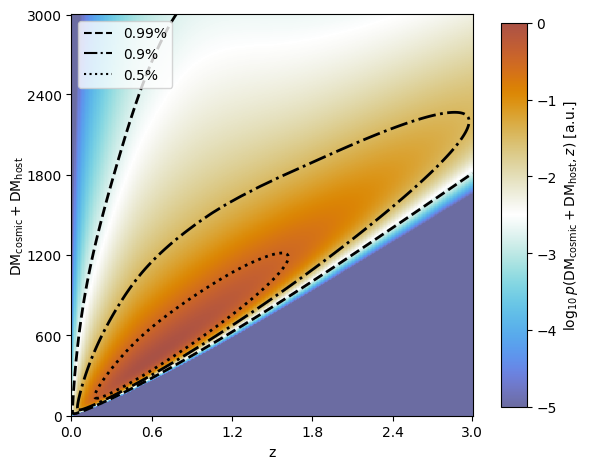

Loading survey: MeerTRAPcoherent from MeerTRAPcoherent.ecsv
Loaded FRB info
FRB survey sucessfully initialised with  1  FRBs starting from 0


/Users/lmasriba/FRBs/zdm/zdm/figures.py:316: RuntimeWarning: divide by zero encountered in log10
  zDMgrid = np.log10(zDMgrid)


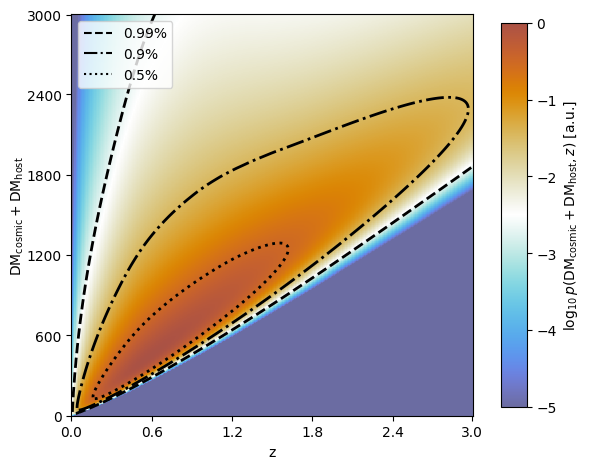

Loading survey: MeerTRAPcoherent from MeerTRAPcoherent.ecsv
Loaded FRB info
FRB survey sucessfully initialised with  1  FRBs starting from 0


/Users/lmasriba/FRBs/zdm/zdm/figures.py:316: RuntimeWarning: divide by zero encountered in log10
  zDMgrid = np.log10(zDMgrid)


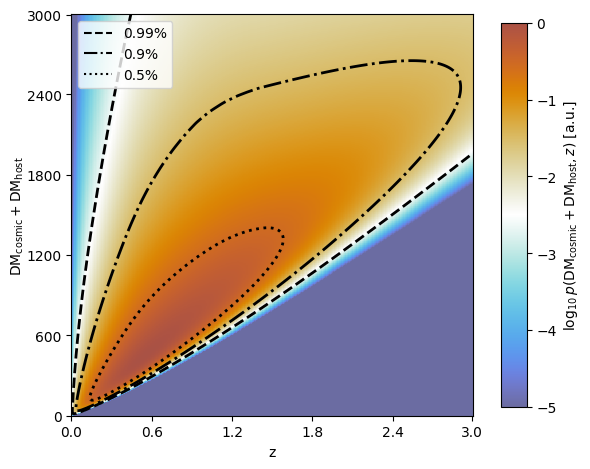

Loading survey: MeerTRAPcoherent from MeerTRAPcoherent.ecsv
Loaded FRB info
FRB survey sucessfully initialised with  1  FRBs starting from 0


/Users/lmasriba/FRBs/zdm/zdm/figures.py:316: RuntimeWarning: divide by zero encountered in log10
  zDMgrid = np.log10(zDMgrid)


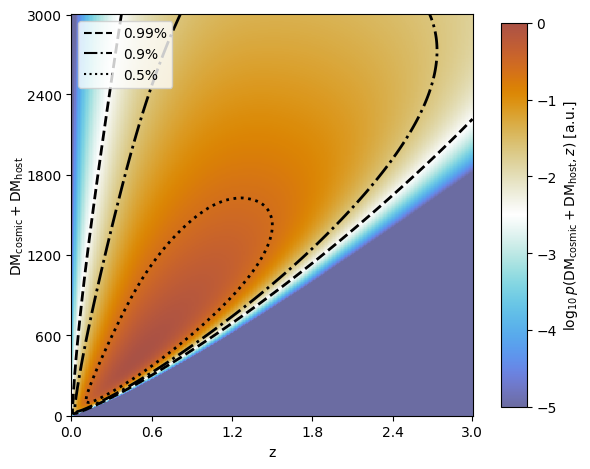

In [16]:
main()

In [12]:
also check what i did for cross correlation chime clean, how to plot meertrap and then how jordan did the caleb plot 

SyntaxError: invalid syntax (3278127899.py, line 1)